In [1]:
from src import sph_cpp
from src.visualization import *
import matplotlib.pyplot as plt

### Define simulation parameters

In [2]:
res = 0.1
no_steps = 100
Lx = 5.0
Ly = 5.0
rho0 = 1.0
kappa = 1.2
v0 = 10
dt = 0.01
c_s = 0.1
beta = 0.07

central_radius = 0.1
boundary_width = 0.02
max_force = 1000

### Run simulation

In [3]:
params = sph_cpp.SimulationParams(
    res, no_steps, Lx, Ly, rho0, kappa, v0, dt, c_s, beta, central_radius, boundary_width, max_force
)

# Initialize ParticleList
particle_list = sph_cpp.ParticleList(params)

# Setup initial conditions
particle_list.init_random()
particle_list.init_mass()
particle_list.init_vel()

# Run simulation
rerun_sim = True
if rerun_sim:
    particle_list.integrate()

Nx = int(Lx/res)
Ny = int(Ly/res)
init_particles = Nx*Ny
masses = np.array([params.rho0*params.Lx*params.Ly/params.init_particles]*params.init_particles)

### Read data

In [4]:
positions, velocities = read_all_output("all_output.bin")

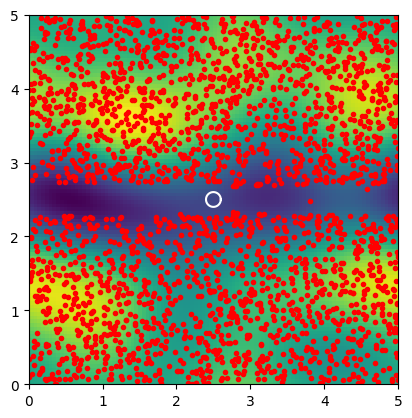

In [5]:
idx = 50

fig, ax = plt.subplots()
ax.set_xlim(0,float(params.Lx))
ax.set_ylim(0,float(params.Ly))
ax.set_aspect("equal")

# Plot particles
particles, = ax.plot(positions[idx,:,0], positions[idx,:,1], linestyle="None", marker=".", color="red")

# Plot central object
phi = np.linspace(0,2*np.pi,100)
ax.plot(params.Lx/2.0+params.central_radius*np.cos(phi), params.Ly/2.0+params.central_radius*np.sin(phi), color="white")

# Plot field
x,y,vx,vy,v = get_velocity_grid(positions[idx], velocities[idx], masses, params)
field = ax.pcolor(x,y,v)

plt.show()

### Create animation

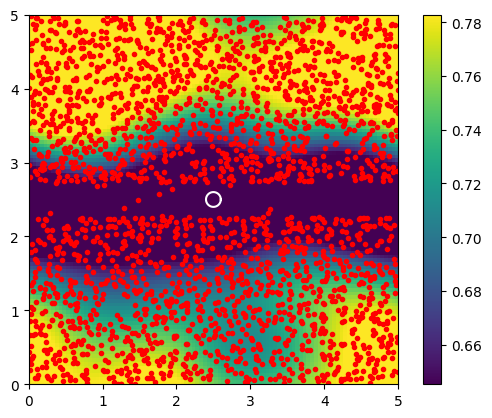

In [8]:
animate(positions[::10], velocities[::10], params, masses, field_type="density")

### Energy calculation

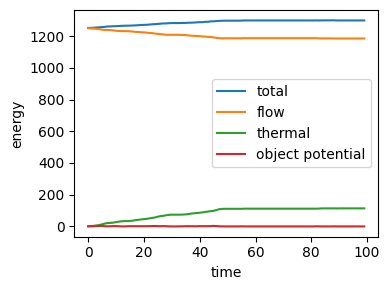

In [ ]:
E_total, E_bulk, E_rand, E_object = calculate_energies(positions, velocities, params, masses)

fig, ax = plt.subplots(figsize=(4,3))
ax.plot(E_total, label="total")
ax.plot(E_bulk, label="flow")
ax.plot(E_rand, label="thermal")
ax.plot(E_object, label="object potential")
ax.set_xlabel("time")
ax.set_ylabel("energy")
ax.legend()
fig.tight_layout()
fig.savefig("figures/energy_leapfrog.png", dpi=300)
plt.show()